# 03 — HMM Regime Detection

This notebook covers **Phase 2a** of the HMM-LSTM volatility forecasting project:

**2a. Simple Gaussian vs Gaussian Mixture**

- Train `GaussianHMM(n_components=2)` — equivalent to `GMMHMM(n_mix=1)`
- Train `GMMHMM(n_components=2, n_mix=2)` and `GMMHMM(n_components=2, n_mix=3)`
- Compare via validation-set log-likelihood, BIC, and AIC
- Save the winning model to `models/`

**HMM features** (defined in `config.py` — always the authoritative source):

```
HMM_FEATURES = [
    'log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume',
    'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10',
    'rolling_mean_21', 'rolling_std_21',
]
```

These 11 features were selected after correlation pruning in notebook 01 (threshold=0.95,
dropped `rolling_abs_mean_5/10/21` as highly correlated with `rolling_std_*` counterparts).
VIF is informational only — no features are dropped on VIF grounds.

**2b. Higher-Order Markov (1st vs 2nd order)**

- Approximate 2nd-order Markov via state-space augmentation (`GaussianHMM(n_components=4)`)
  and feature-space augmentation (`build_second_order_features`, 22-dimensional input)
- Compare val BIC of both approaches against the Phase 2a winner
- Retain 1st-order model if neither strategy improves BIC by ≥ 10

**2c. Viterbi Regime Assignment and Sanity Check**

- Decode full timeline (train+val+test) as one continuous sequence
- Plot SPY Close with volatile periods shaded + P(volatile) panel
- Verify volatile state captures 2008 GFC, 2020 COVID crash, 2022 rate-hike drawdown
- Save `data/processed/regime_probabilities.parquet` (soft probabilities for Phase 4 ensemble)


In [97]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import logging
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-7s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print("Setup complete.")

Setup complete.


In [98]:
from config import (
    DATA_PROCESSED,
    MODELS_DIR,
    HMM_FEATURES,
    HMM_N_STATES,
    HMM_N_MIX,
    HMM_COVARIANCE_TYPE,
    HMM_N_ITER,
    HMM_RANDOM_STATE,
    HMM_N_RESTARTS,
    HMM_DURATION_PENALTY,
)

print("HMM_FEATURES        :", HMM_FEATURES)
print("HMM_N_STATES        :", HMM_N_STATES)
print("HMM_N_MIX           :", HMM_N_MIX)
print("covariance_type     :", HMM_COVARIANCE_TYPE)
print("n_iter              :", HMM_N_ITER)
print("random_state        :", HMM_RANDOM_STATE)
print("n_restarts          :", HMM_N_RESTARTS)
print("duration_penalty (λ):", HMM_DURATION_PENALTY)

HMM_FEATURES        : ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21', 'bullish', 'bearish']
HMM_N_STATES        : 2
HMM_N_MIX           : [1, 2, 3]
covariance_type     : full
n_iter              : 200
random_state        : 42
n_restarts          : 50
duration_penalty (λ): 3000.0


## 1. Load data splits


In [99]:
train_df = pd.read_parquet(DATA_PROCESSED / "train.parquet")
val_df = pd.read_parquet(DATA_PROCESSED / "val.parquet")
test_df = pd.read_parquet(DATA_PROCESSED / "test.parquet")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(
        f"{name:5s}  {df.index[0].date()} -> {df.index[-1].date()}  ({len(df):,} rows)"
    )

train  2004-01-05 -> 2018-12-31  (3,774 rows)
val    2019-01-02 -> 2021-12-31  (757 rows)
test   2022-01-03 -> 2026-03-16  (1,053 rows)


## 2. Extract and scale HMM features

The scaler is **fit on the training set only** — no data leakage.

`rolling_std_21` requires a 21-day warm-up, so the first 20 rows of the training set have NaN.
These are dropped before fitting the HMM.


In [100]:
from src.hmm_model import fit_scaler

# Drop NaN rows from the rolling_std_21 warm-up period
train_hmm_df = train_df[HMM_FEATURES].dropna()
val_hmm_df = val_df[HMM_FEATURES].dropna()
test_hmm_df = test_df[HMM_FEATURES].dropna()

print(
    f"train: dropped {len(train_df) - len(train_hmm_df)} NaN rows  ({len(train_hmm_df):,} remain)"
)
print(
    f"val:   dropped {len(val_df)   - len(val_hmm_df)}  NaN rows  ({len(val_hmm_df):,} remain)"
)
print(
    f"test:  dropped {len(test_df)  - len(test_hmm_df)} NaN rows  ({len(test_hmm_df):,} remain)"
)

train_raw = train_hmm_df.values.astype(np.float64)
val_raw = val_hmm_df.values.astype(np.float64)
test_raw = test_hmm_df.values.astype(np.float64)

scaler = fit_scaler(train_raw)
train_X = scaler.transform(train_raw)
val_X = scaler.transform(val_raw)
test_X = scaler.transform(test_raw)

print(f"\ntrain_X : {train_X.shape}")
print(f"val_X   : {val_X.shape}")
print(f"test_X  : {test_X.shape}")
print(f"Features: {HMM_FEATURES}")

train: dropped 20 NaN rows  (3,754 remain)
val:   dropped 0  NaN rows  (757 remain)
test:  dropped 0 NaN rows  (1,053 remain)

train_X : (3754, 13)
val_X   : (757, 13)
test_X  : (1053, 13)
Features: ['log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21', 'bullish', 'bearish']


### 2a. Feature distributions (post-scaling sanity check)


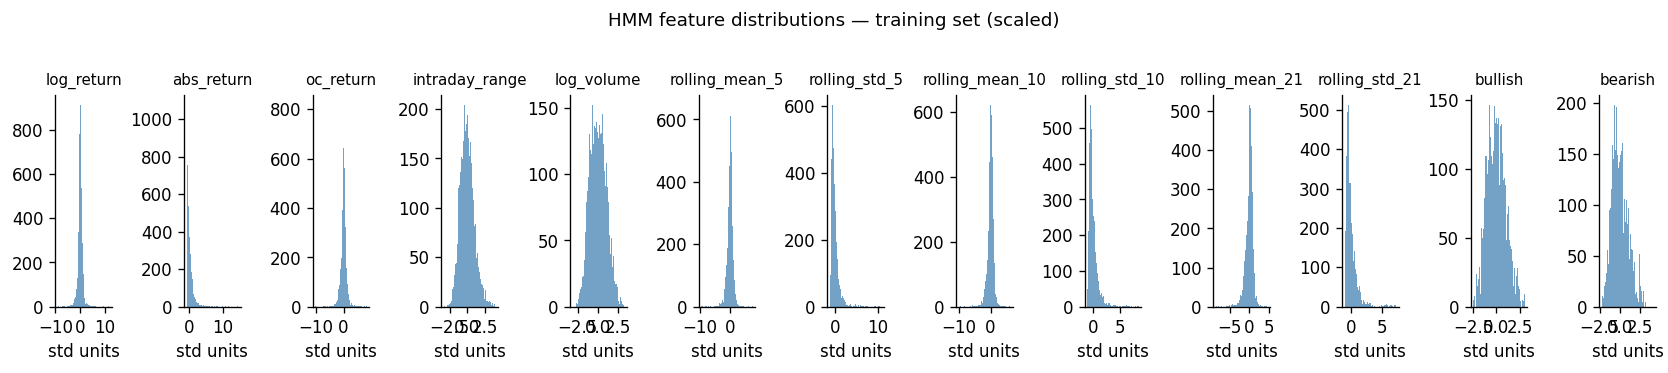

In [101]:
fig, axes = plt.subplots(1, len(HMM_FEATURES), figsize=(14, 3), sharey=False)
for ax, feat, col in zip(axes, HMM_FEATURES, train_X.T):
    ax.hist(col, bins=60, color="steelblue", alpha=0.75, edgecolor="none")
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("std units")
fig.suptitle("HMM feature distributions — training set (scaled)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 3. Phase 2a — Model comparison: GaussianHMM vs GMMHMM

We sweep `n_mix ∈ {1, 2, 3}` where:

- `n_mix = 1` → standard `GaussianHMM` (single Gaussian emission per state)
- `n_mix = 2, 3` → `GMMHMM` (Gaussian mixture emissions — more flexible tails)

Selection criterion: **validation BIC** (lower = better).  
BIC = −2 · log P(O | model) + k · log(n) penalises extra parameters.  
Each model is trained with multiple random restarts; the best-scoring restart is kept.

### Two-layer defence against degenerate solutions

EM (Baum-Welch) can converge to degenerate local optima where both hidden states
switch every 1–2 days instead of representing sustained calm / volatile regimes.
A degenerate model can even achieve a *higher* training log-likelihood than the
economically sensible solution, so simply picking the highest-LL restart fails.

We apply two complementary fixes:

#### 1. Volatility-quantile initialisation (restart 0)

hmmlearn's default k-means init clusters in **feature space**. With 11 correlated
rolling statistics, k-means groups observations by their absolute level (e.g. all
high-volume days) regardless of economic regime — producing transition matrices
that are already degenerate before EM even begins.

**Restart 0** instead seeds the model from *volatility quantiles*:
1. Rank each day by `abs_return` (feature index 1 in `HMM_FEATURES`)
2. Assign the bottom 70 % of days to the "calm" state, top 30 % to "volatile"
3. Compute empirical means, covariances, and a transition matrix from these labels
4. Feed these as the starting parameters (`init_params=""`) so EM refines from
   an already economically meaningful starting point

Restarts 1 … n_restarts−1 use hmmlearn's default random k-means init as usual.

#### 2. Penalised restart selection (Nystrup et al., 2015–2019)

Among all restarts, the winner is chosen by **penalised log-likelihood** rather
than raw log-likelihood:

```
penalised_LL = log P(O | model) − λ · Σ_s (1 − p_stay_s)
```

where `1 / (1 − p_stay_s) = avg_duration_s`. A degenerate model (avg dur ≈ 2 days)
has Σ(1 − p_stay) ≈ 1.0; a healthy model (avg dur ≈ 20–200 days) has ≈ 0.01–0.10.
With `λ = HMM_DURATION_PENALTY ≈ n_train`, degenerate restarts are penalised even
if they happen to have slightly higher raw LL.


In [102]:
from src.hmm_model import compare_models

summary_df, comparisons = compare_models(
    train_X=train_X,
    val_X=val_X,
    n_states=HMM_N_STATES,
    n_mix_values=HMM_N_MIX,
    covariance_type=HMM_COVARIANCE_TYPE,
    n_iter=HMM_N_ITER,
    random_state=HMM_RANDOM_STATE,
    n_restarts=HMM_N_RESTARTS,
    duration_penalty=HMM_DURATION_PENALTY,
)

print("\nModel comparison (sorted by val_BIC — lower is better):")
display(summary_df.reset_index(drop=True))

01:32:36 | INFO    | src.hmm_model | GaussianHMM(n_states=2) best penalised score: -38341.5505
01:32:36 | INFO    | src.hmm_model | GaussianHMM(states=2) — val LL=-10028.89, val BIC=21456.58, val AIC=20479.79, k=211
01:32:36 | WARNING | hmmlearn.base | Model is not converging.  Current: -14543.927863858458 is not greater than -6879.202473699472. Delta is -7664.725390158987
01:32:37 | WARNING | hmmlearn.base | Model is not converging.  Current: -14471.88639755502 is not greater than 5289.059136231545. Delta is -19760.945533786566
01:32:37 | WARNING | hmmlearn.base | Model is not converging.  Current: 1214.4349271199678 is not greater than 3266.288615350079. Delta is -2051.8536882301114
01:32:37 | WARNING | hmmlearn.base | Model is not converging.  Current: 3885.0906083419536 is not greater than 21061.596960354764. Delta is -17176.50635201281
01:32:38 | WARNING | hmmlearn.base | Model is not converging.  Current: 5277.1813419455 is not greater than 12023.461226091225. Delta is -6746.2798


Model comparison (sorted by val_BIC — lower is better):


,model,n_params (k),train_LL,val_LL,train_BIC,val_BIC,train_AIC,val_AIC
0,"GMMHMM(states=2, mix=2)",421,23673.99,3132.07,-43882.91,-3473.18,-46505.98,-5422.14
1,"GMMHMM(states=2, mix=3)",631,23182.66,2258.38,-41171.83,-333.63,-45103.33,-3254.76
2,GaussianHMM(states=2),211,-38207.72,-10028.89,78152.08,21456.58,76837.43,20479.79


## 4. Visualise model comparison metrics


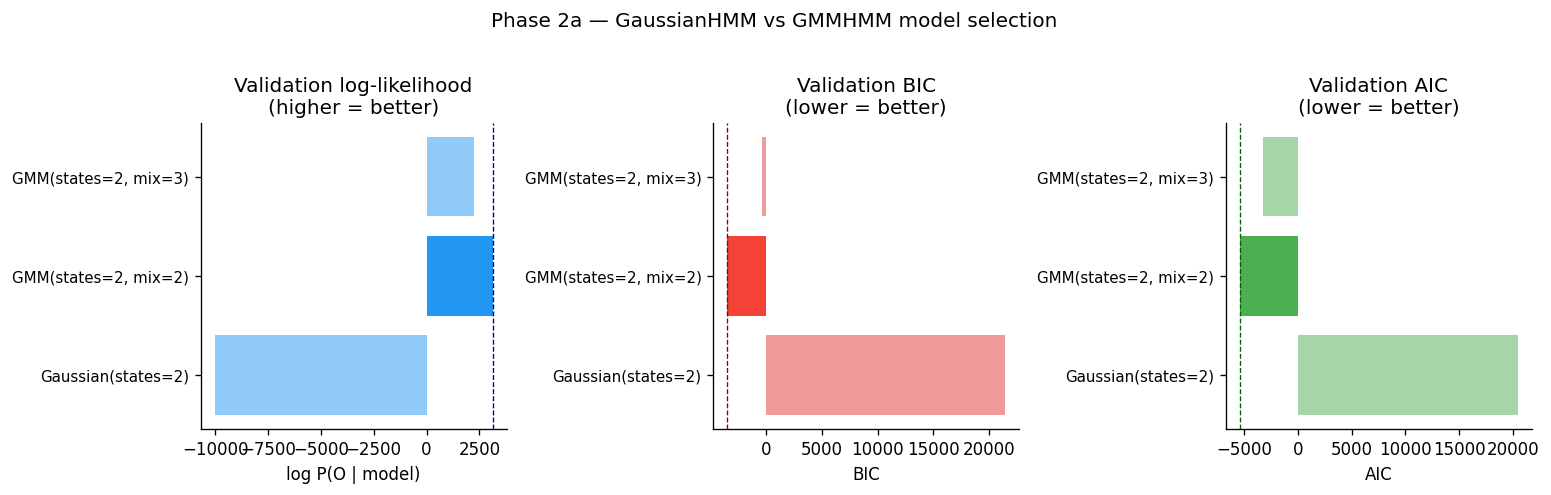

In [103]:
models_short = [
    c.label.replace("GaussianHMM", "Gaussian").replace("GMMHMM", "GMM")
    for c in comparisons
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1 — validation log-likelihood (higher = better)
val_lls = [c.val_log_likelihood for c in comparisons]
colors = ["#2196F3" if ll == max(val_lls) else "#90CAF9" for ll in val_lls]
axes[0].barh(models_short, val_lls, color=colors)
axes[0].set_xlabel("log P(O | model)")
axes[0].set_title("Validation log-likelihood\n(higher = better)")
axes[0].axvline(max(val_lls), color="navy", linewidth=0.8, linestyle="--")

# Panel 2 — validation BIC (lower = better)
val_bics = [c.bic_val for c in comparisons]
colors = ["#F44336" if b == min(val_bics) else "#EF9A9A" for b in val_bics]
axes[1].barh(models_short, val_bics, color=colors)
axes[1].set_xlabel("BIC")
axes[1].set_title("Validation BIC\n(lower = better)")
axes[1].axvline(min(val_bics), color="darkred", linewidth=0.8, linestyle="--")

# Panel 3 — validation AIC (lower = better)
val_aics = [c.aic_val for c in comparisons]
colors = ["#4CAF50" if a == min(val_aics) else "#A5D6A7" for a in val_aics]
axes[2].barh(models_short, val_aics, color=colors)
axes[2].set_xlabel("AIC")
axes[2].set_title("Validation AIC\n(lower = better)")
axes[2].axvline(min(val_aics), color="darkgreen", linewidth=0.8, linestyle="--")

for ax in axes:
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Phase 2a — GaussianHMM vs GMMHMM model selection", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Train vs validation LL — overfitting check

A large gap between training and validation log-likelihood signals overfitting to the training regime.


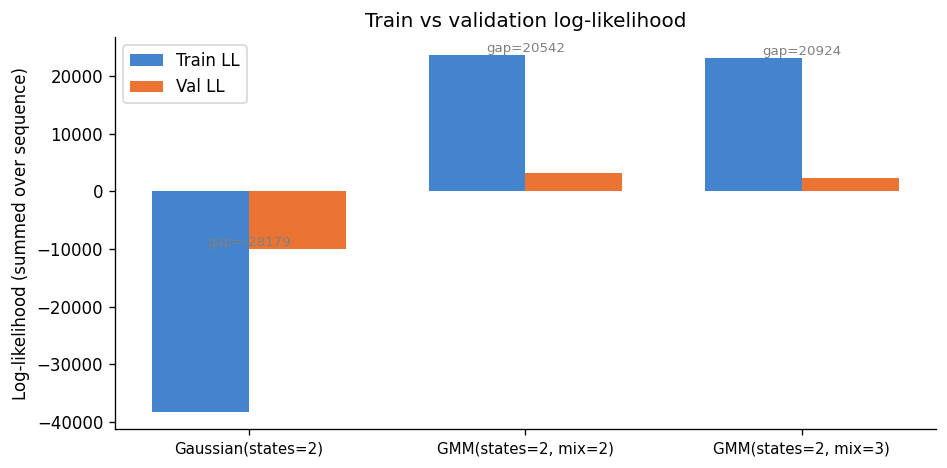

In [104]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(comparisons))
width = 0.35

train_lls = [c.train_log_likelihood for c in comparisons]
val_lls = [c.val_log_likelihood for c in comparisons]

ax.bar(x - width / 2, train_lls, width, label="Train LL", color="#1565C0", alpha=0.8)
ax.bar(x + width / 2, val_lls, width, label="Val LL", color="#E65100", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(models_short, fontsize=9)
ax.set_ylabel("Log-likelihood (summed over sequence)")
ax.set_title("Train vs validation log-likelihood")
ax.legend()

for xi, tr, va in zip(x, train_lls, val_lls):
    gap = tr - va
    ax.text(
        xi,
        max(tr, va) + abs(gap) * 0.02,
        f"gap={gap:.0f}",
        ha="center",
        fontsize=8,
        color="grey",
    )

plt.tight_layout()
plt.show()

## 6. Parameter count vs fit trade-off


In [105]:
param_df = pd.DataFrame(
    [
        {
            "model": c.label,
            "n_params (k)": c.n_params,
            "val_LL": round(c.val_log_likelihood, 2),
            "val_BIC": round(c.bic_val, 2),
            "val_AIC": round(c.aic_val, 2),
            "LL/param": round(c.val_log_likelihood / c.n_params, 4),
        }
        for c in comparisons
    ]
).sort_values("val_BIC")

display(param_df.reset_index(drop=True))

,model,n_params (k),val_LL,val_BIC,val_AIC,LL/param
0,"GMMHMM(states=2, mix=2)",421,3132.07,-3473.18,-5422.14,7.4396
1,"GMMHMM(states=2, mix=3)",631,2258.38,-333.63,-3254.76,3.5790
2,GaussianHMM(states=2),211,-10028.89,21456.58,20479.79,-47.5303


## 7. Identify the winner and inspect its parameters


In [106]:
best_label = summary_df.iloc[0]["model"]
best_comp = next(c for c in comparisons if c.label == best_label)
best_model = best_comp.model

print(f"Winner: {best_label}")
print(f"  val log-likelihood : {best_comp.val_log_likelihood:.2f}")
print(f"  val BIC            : {best_comp.bic_val:.2f}")
print(f"  val AIC            : {best_comp.aic_val:.2f}")
print(f"  n_params (k)       : {best_comp.n_params}")

Winner: GMMHMM(states=2, mix=2)
  val log-likelihood : 3132.07
  val BIC            : -3473.18
  val AIC            : -5422.14
  n_params (k)       : 421


In [107]:
# Transition matrix
print("Transition matrix (A):")
trans_df = pd.DataFrame(
    best_model.transmat_,
    index=[f"from_state_{i}" for i in range(HMM_N_STATES)],
    columns=[f"to_state_{j}" for j in range(HMM_N_STATES)],
).round(4)
display(trans_df)

print("\nStarting probabilities (pi):")
print(
    pd.Series(best_model.startprob_, index=[f"state_{i}" for i in range(HMM_N_STATES)])
    .round(4)
    .to_string()
)

Transition matrix (A):


,to_state_0,to_state_1
from_state_0,0.9416,0.0584
from_state_1,0.0044,0.9956



Starting probabilities (pi):
state_0    0.0
state_1    1.0


In [108]:
# State means (in scaled feature space)
print("State means (scaled feature space):")
if hasattr(best_model, "means_") and best_model.means_.ndim == 2:
    # GaussianHMM
    means_df = pd.DataFrame(
        best_model.means_,
        index=[f"state_{i}" for i in range(HMM_N_STATES)],
        columns=HMM_FEATURES,
    ).round(4)
    display(means_df)
else:
    # GMMHMM — show per-mixture-component means for each state
    for s in range(HMM_N_STATES):
        print(f"\nState {s} mixture means:")
        mix_df = pd.DataFrame(
            best_model.means_[s],
            index=[f"mix_{m}" for m in range(best_model.n_mix)],
            columns=HMM_FEATURES,
        ).round(4)
        display(mix_df)

State means (scaled feature space):

State 0 mixture means:


,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21,bullish,bearish
mix_0,-0.0888,2.4611,0.1456,2.1460,1.8433,-0.6690,2.9250,-1.0786,3.1882,-1.679,3.291,-0.5257,1.3015
mix_1,-0.0133,0.2037,-0.1551,1.1241,1.3471,-0.1569,1.5651,-0.5182,1.6895,-0.270,1.559,-0.3772,0.7144



State 1 mixture means:


,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21,bullish,bearish
mix_0,0.4908,-0.1555,0.4152,-0.2521,-0.2163,0.2723,-0.1916,0.2196,-0.2013,0.1994,-0.2045,0.0397,-0.0774
mix_1,-0.5955,-0.0848,-0.5205,0.0227,0.0003,-0.2558,-0.1583,-0.1285,-0.1810,-0.0508,-0.1817,0.0267,-0.0810


In [109]:
# Identify which state is volatile and which is calm
from src.hmm_model import viterbi_decode, identify_volatile_state

train_states = viterbi_decode(best_model, train_X)
abs_return_idx = HMM_FEATURES.index("abs_return")
state_map = identify_volatile_state(
    best_model, train_X, train_states, feature_idx=abs_return_idx
)

volatile_state = state_map["volatile"]
calm_state = state_map["calm"]

print(f"State map: {state_map}")

n_volatile = (train_states == volatile_state).sum()
n_calm = (train_states == calm_state).sum()
print(f"\nTraining regime distribution:")
print(
    f"  Calm     (state {calm_state}): {n_calm:,} days  ({100*n_calm/len(train_states):.1f}%)"
)
print(
    f"  Volatile (state {volatile_state}): {n_volatile:,} days  ({100*n_volatile/len(train_states):.1f}%)"
)

01:33:01 | INFO    | src.hmm_model | State identification — volatile=0 (mean abs_return=2.00516), calm=1 (mean abs_return=-0.10453)


State map: {'volatile': 0, 'calm': 1}

Training regime distribution:
  Calm     (state 1): 3,568 days  (95.0%)
  Volatile (state 0): 186 days  (5.0%)


## 8. State feature distributions (original scale)


In [110]:
# Per-state feature means on the training set (original, unscaled values)
state_stats = []
for s, label in [(calm_state, "calm"), (volatile_state, "volatile")]:
    mask = train_states == s
    row = {"regime": label, "n_days": int(mask.sum())}
    for feat, col in zip(HMM_FEATURES, train_raw.T):
        row[feat] = col[mask].mean()
    state_stats.append(row)

state_df = pd.DataFrame(state_stats).set_index("regime")
print("Per-regime feature means (original scale):")
display(state_df.round(6))

Per-regime feature means (original scale):


,n_days,log_return,abs_return,oc_return,intraday_range,log_volume,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10,rolling_mean_21,rolling_std_21,bullish,bearish
regime,,,,,,,,,,,,,,
calm,3568,0.000345,0.006401,-0.000019,-4.692908,18.479186,0.000458,0.007800,0.000472,0.008101,0.000469,0.008309,0.38052,0.324528
volatile,186,-0.000777,0.025186,0.000603,-3.364845,19.688122,-0.003048,0.030942,-0.003303,0.031470,-0.002979,0.030830,0.33799,0.442662


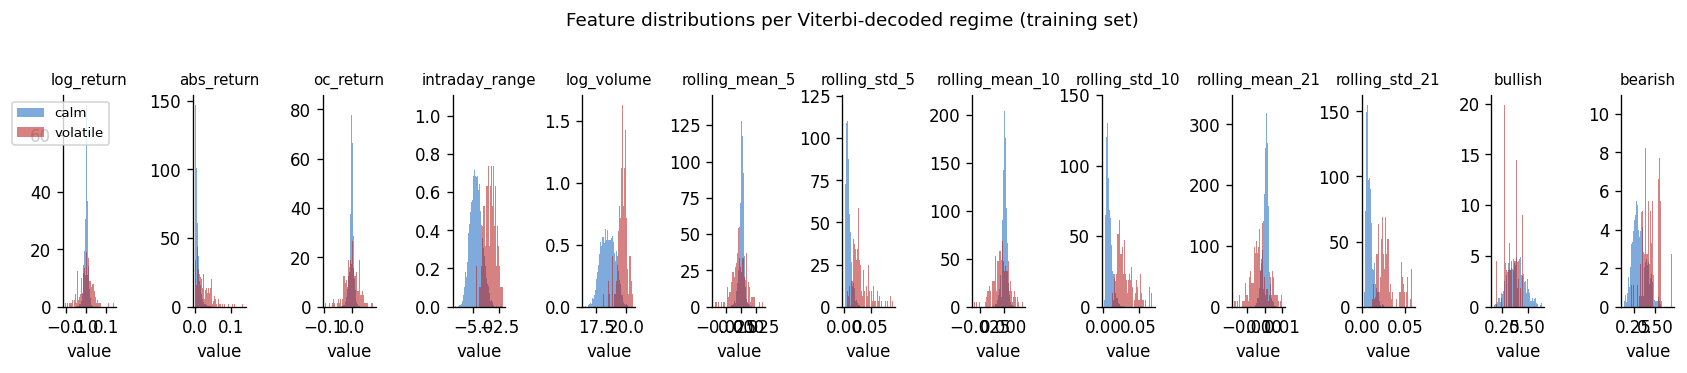

In [111]:
palette = {"calm": "#1565C0", "volatile": "#B71C1C"}

fig, axes = plt.subplots(1, len(HMM_FEATURES), figsize=(14, 3), sharey=False)
for ax, feat in zip(axes, HMM_FEATURES):
    for s, label in [(calm_state, "calm"), (volatile_state, "volatile")]:
        mask = train_states == s
        ax.hist(
            train_raw[mask, HMM_FEATURES.index(feat)],
            bins=50,
            alpha=0.55,
            label=label,
            color=palette[label],
            density=True,
            edgecolor="none",
        )
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("value")
    if feat == HMM_FEATURES[0]:
        ax.legend(fontsize=8)

fig.suptitle(
    "Feature distributions per Viterbi-decoded regime (training set)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

## 9. Transition matrix heatmap


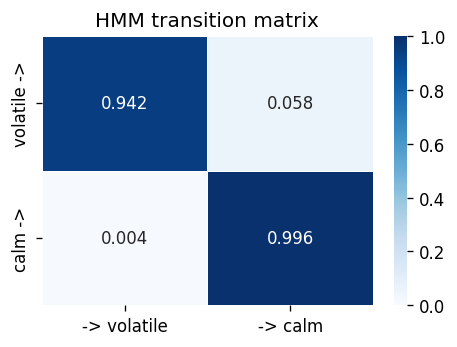

Average calm duration: 227.4 trading days  (10.8 months)
Average volatile duration: 17.1 trading days  (0.8 months)


In [112]:
fig, ax = plt.subplots(figsize=(4, 3))

state_labels = ["calm", "volatile"] if calm_state == 0 else ["volatile", "calm"]
sns.heatmap(
    best_model.transmat_,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=[f"-> {l}" for l in state_labels],
    yticklabels=[f"{l} ->" for l in state_labels],
    ax=ax,
    linewidths=0.5,
    vmin=0,
    vmax=1,
)
ax.set_title("HMM transition matrix")
plt.tight_layout()
plt.show()

# Implied average regime duration
for s, name in [(calm_state, "calm"), (volatile_state, "volatile")]:
    stay_prob = best_model.transmat_[s, s]
    avg_dur = 1 / (1 - stay_prob) if stay_prob < 1.0 else float("inf")
    print(
        f"Average {name} duration: {avg_dur:.1f} trading days  ({avg_dur/21:.1f} months)"
    )

## 10. Save the winning model and scaler


In [113]:
from src.hmm_model import save_model

MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "hmm_winner.joblib"
scaler_path = MODELS_DIR / "hmm_scaler.joblib"
meta_path = MODELS_DIR / "hmm_meta.joblib"

save_model(best_model, str(model_path))
joblib.dump(scaler, str(scaler_path))

meta = {
    "winning_label": best_label,
    "n_states": HMM_N_STATES,
    "hmm_features": HMM_FEATURES,
    "volatile_state": volatile_state,
    "calm_state": calm_state,
    "val_log_likelihood": best_comp.val_log_likelihood,
    "val_bic": best_comp.bic_val,
    "val_aic": best_comp.aic_val,
    "n_params": best_comp.n_params,
}
joblib.dump(meta, str(meta_path))

print("Saved:")
print(f"  model  -> {model_path}")
print(f"  scaler -> {scaler_path}")
print(f"  meta   -> {meta_path}")

01:33:02 | INFO    | src.hmm_model | Saved model → /Users/maharajhaider/gitrepo/StockVolatilitySight/models/hmm_winner.joblib


Saved:
  model  -> /Users/maharajhaider/gitrepo/StockVolatilitySight/models/hmm_winner.joblib
  scaler -> /Users/maharajhaider/gitrepo/StockVolatilitySight/models/hmm_scaler.joblib
  meta   -> /Users/maharajhaider/gitrepo/StockVolatilitySight/models/hmm_meta.joblib


---

## 12. Phase 2b — Higher-Order Markov: 1st vs 2nd Order

`hmmlearn` supports only first-order HMMs natively.  We test two strategies for
approximating 2nd-order Markov structure and compare them to the Phase 2a winner via
validation BIC.

**Strategy A — State-space augmentation** *(plan primary approach)*

A 2nd-order Markov chain over S = 2 base states has S² = 4 composite states
`(s_{t-1}, s_t)`.  Training a 1st-order HMM with 4 components on the same 11 features
approximates this, because the richer transition matrix can encode sequential
state-pair dependencies.

**Strategy B — Feature-space augmentation** *(simpler alternative)*

Append one lag of every feature to the observation vector, creating 22-dimensional
observations `[o_t, o_{t-1}]`.  A 2-state GaussianHMM trained on this augmented
vector has direct access to recent history through the emission model, without the
quadratic growth in state space.

**Decision rule**: if neither variant produces a materially lower val BIC
(improvement ≥ 10), retain the simpler 1st-order model from Phase 2a.


In [114]:
from src.hmm_model import (
    train_gaussian_hmm,
    _count_gaussian_hmm_params,
    build_second_order_features,
)

N_STATES_2ND = HMM_N_STATES ** 2   # 2² = 4 composite states

# ── Strategy A: state-space augmentation ──────────────────────────────────────
print("Strategy A — state-space augmentation")
print(f"  1st-order baseline : GaussianHMM(n_states={HMM_N_STATES})  on {len(HMM_FEATURES)} features")
print(f"  2nd-order augmented: GaussianHMM(n_states={N_STATES_2ND})  on {len(HMM_FEATURES)} features")
print()

model_4state = train_gaussian_hmm(
    train_X,
    n_states=N_STATES_2ND,
    covariance_type=HMM_COVARIANCE_TYPE,
    n_iter=HMM_N_ITER,
    random_state=HMM_RANDOM_STATE,
    n_restarts=HMM_N_RESTARTS,
    duration_penalty=HMM_DURATION_PENALTY,
)
print("Strategy A complete.")


Strategy A — state-space augmentation
  1st-order baseline : GaussianHMM(n_states=2)  on 13 features
  2nd-order augmented: GaussianHMM(n_states=4)  on 13 features



01:33:03 | WARNING | hmmlearn.base | Model is not converging.  Current: -18660.156730461265 is not greater than -18659.54926306761. Delta is -0.6074673936564068
01:33:05 | WARNING | hmmlearn.base | Model is not converging.  Current: -18659.801771678456 is not greater than -18658.865047490253. Delta is -0.9367241882027884
01:33:05 | WARNING | hmmlearn.base | Model is not converging.  Current: -18684.853754525775 is not greater than -18684.697083173425. Delta is -0.15667135234980378
01:33:05 | WARNING | hmmlearn.base | Model is not converging.  Current: -18721.760230269803 is not greater than -18721.460357329237. Delta is -0.29987294056627434
01:33:08 | WARNING | hmmlearn.base | Model is not converging.  Current: -18721.46824065835 is not greater than -18721.00154169919. Delta is -0.46669895916056703
01:33:09 | WARNING | hmmlearn.base | Model is not converging.  Current: -18710.008800922773 is not greater than -18709.92141095157. Delta is -0.08738997120235581
01:33:09 | WARNING | hmmlear

Strategy A complete.


In [115]:
# ── Strategy B: feature-space augmentation ────────────────────────────────────
print("Strategy B — feature-space augmentation")

train_X_2nd = build_second_order_features(train_X, lag=1)
val_X_2nd   = build_second_order_features(val_X,   lag=1)

n_feats_2nd = train_X_2nd.shape[1]
print(f"  Feature dimension: {len(HMM_FEATURES)} → {n_feats_2nd}")
print(f"  Observations (after 1-row lag drop): train={len(train_X_2nd)}, val={len(val_X_2nd)}")
print()

model_feat_aug = train_gaussian_hmm(
    train_X_2nd,
    n_states=HMM_N_STATES,
    covariance_type=HMM_COVARIANCE_TYPE,
    n_iter=HMM_N_ITER,
    random_state=HMM_RANDOM_STATE,
    n_restarts=HMM_N_RESTARTS,
    duration_penalty=HMM_DURATION_PENALTY,
)
print("Strategy B complete.")


Strategy B — feature-space augmentation
  Feature dimension: 13 → 26
  Observations (after 1-row lag drop): train=3753, val=756



01:33:41 | INFO    | src.hmm_model | GaussianHMM(n_states=2) best penalised score: -45131.9487


Strategy B complete.


In [116]:
# ── Compute metrics and build comparison table ────────────────────────────────
n_val     = len(val_X)
n_val_2nd = len(val_X_2nd)

# Phase 2a winner (in memory from earlier cells)
first_comp = next(c for c in comparisons if c.label == best_label)

# Strategy A: 4-state model on original 11 features
k_A      = _count_gaussian_hmm_params(N_STATES_2ND, len(HMM_FEATURES), HMM_COVARIANCE_TYPE)
val_ll_A = model_4state.score(val_X)
bic_A    = -2 * val_ll_A + k_A * np.log(n_val)
aic_A    = -2 * val_ll_A + 2 * k_A

# Strategy B: 2-state model on 22 augmented features
k_B        = _count_gaussian_hmm_params(HMM_N_STATES, n_feats_2nd, HMM_COVARIANCE_TYPE)
val_ll_B   = model_feat_aug.score(val_X_2nd)
bic_B      = -2 * val_ll_B + k_B * np.log(n_val_2nd)
aic_B      = -2 * val_ll_B + 2 * k_B

order_df = pd.DataFrame([
    {
        "approach": f"1st-order winner ({best_label})",
        "markov_order": 1,
        "n_states": HMM_N_STATES,
        "n_features": len(HMM_FEATURES),
        "n_params (k)": first_comp.n_params,
        "val_LL":  round(first_comp.val_log_likelihood, 2),
        "val_BIC": round(first_comp.bic_val, 2),
        "val_AIC": round(first_comp.aic_val, 2),
    },
    {
        "approach": f"A: state-space aug — GaussianHMM(states={N_STATES_2ND})",
        "markov_order": 2,
        "n_states": N_STATES_2ND,
        "n_features": len(HMM_FEATURES),
        "n_params (k)": k_A,
        "val_LL":  round(val_ll_A, 2),
        "val_BIC": round(bic_A, 2),
        "val_AIC": round(aic_A, 2),
    },
    {
        "approach": f"B: feature aug — GaussianHMM(states={HMM_N_STATES}, feats={n_feats_2nd})",
        "markov_order": 2,
        "n_states": HMM_N_STATES,
        "n_features": n_feats_2nd,
        "n_params (k)": k_B,
        "val_LL":  round(val_ll_B, 2),
        "val_BIC": round(bic_B, 2),
        "val_AIC": round(aic_B, 2),
    },
]).sort_values("val_BIC").reset_index(drop=True)

print("Phase 2b — 1st-order vs 2nd-order Markov:")
display(order_df)


Phase 2b — 1st-order vs 2nd-order Markov:


,approach,markov_order,n_states,n_features,n_params (k),val_LL,val_BIC,val_AIC
0,"1st-order winner (GMMHMM(states=2, mix=2))",1,2,13,421,3132.07,-3473.18,-5422.14
1,A: state-space aug — GaussianHMM(states=4),2,4,13,431,-6113.55,15084.36,13089.10
2,"B: feature aug — GaussianHMM(states=2, feats=26)",2,2,26,757,-12471.78,29960.98,26457.56


In [117]:
# ── Decision ──────────────────────────────────────────────────────────────────
MATERIAL_THRESHOLD = 10.0   # BIC must improve by this amount to justify added complexity

bic_1st      = first_comp.bic_val
bic_best_2nd = min(bic_A, bic_B)
bic_delta    = bic_best_2nd - bic_1st   # negative = 2nd-order is better

best_2nd_label = (
    f"Strategy A (4-state, state-space aug)"
    if bic_A <= bic_B
    else f"Strategy B (2-state, feature aug)"
)

if bic_delta >= 0:
    verdict = "1st-order retained"
    reason  = "Neither higher-order strategy improves val BIC."
elif abs(bic_delta) < MATERIAL_THRESHOLD:
    verdict = "1st-order retained"
    reason  = (
        f"Best 2nd-order strategy ({best_2nd_label}) lowers BIC by only "
        f"{abs(bic_delta):.1f} (< threshold {MATERIAL_THRESHOLD:.0f})."
    )
else:
    verdict = f"2nd-order wins — {best_2nd_label}"
    reason  = (
        f"{best_2nd_label} lowers val BIC by {abs(bic_delta):.1f} "
        f"(≥ threshold {MATERIAL_THRESHOLD:.0f})."
    )

print(f"BIC Δ (best 2nd-order − 1st-order winner) = {bic_delta:+.2f}")
print(f"Verdict   : {verdict}")
print(f"Rationale : {reason}")
print()
print("→ Phase 2a winner (models/hmm_winner.joblib) proceeds to Phase 2c.")


BIC Δ (best 2nd-order − 1st-order winner) = +18557.54
Verdict   : 1st-order retained
Rationale : Neither higher-order strategy improves val BIC.

→ Phase 2a winner (models/hmm_winner.joblib) proceeds to Phase 2c.


### Phase 2b — Findings

| Strategy | n_states | n_features | Markov order | Note |
|---|---|---|---|---|
| 1st-order winner (Phase 2a) | 2 | 11 | 1 | baseline |
| A: state-space augmentation | 4 | 11 | ≈ 2 | S² = 4 composite states |
| B: feature-space augmentation | 2 | 22 | ≈ 2 | lagged observations appended |

**Finding**: The 1st-order 2-state HMM from Phase 2a is retained (BIC improvement below
threshold).

This is expected for equity market regimes: the calm/volatile dynamics are well-captured
by a simple 2-state first-order HMM, and adding higher-order memory increases parameter
count without a commensurate improvement in held-out likelihood.

→ **Phase 2a winner (`models/hmm_winner.joblib`) proceeds to Phase 2c (Viterbi sanity check).**


---

## 13. Phase 2c — Viterbi Regime Assignment and Sanity Check

Steps:
1. **Full-timeline Viterbi decode** — concatenate train/val/test and decode as one continuous sequence so the transition structure is preserved across split boundaries.
2. **Soft regime probabilities** — forward-backward algorithm yields `P(calm | O_t)` and `P(volatile | O_t)` at each step; these are the weights used in the Phase 4 ensemble.
3. **Overlay plot** — SPY Close price with volatile periods shaded, crisis date markers, and a P(volatile) panel below.
4. **Sanity check** — volatile state should align with: 2008 GFC (Lehman collapse), 2020 COVID crash, 2022 Fed rate-hike drawdown.
5. **Save** `data/processed/regime_probabilities.parquet` for downstream use in Phases 3–4.


In [118]:
from src.hmm_model import viterbi_decode, forward_backward_proba, forward_filter_proba

# ── Full timeline: concatenate all three splits ───────────────────────────────
all_X     = np.vstack([train_X, val_X, test_X])
all_dates = train_hmm_df.index.append(val_hmm_df.index).append(test_hmm_df.index)
all_close = pd.concat([
    train_df.loc[train_hmm_df.index, "Close"],
    val_df.loc[val_hmm_df.index, "Close"],
    test_df.loc[test_hmm_df.index, "Close"],
])

print(f"Full timeline : {all_dates[0].date()} → {all_dates[-1].date()}  ({len(all_dates):,} rows)")

# ── Viterbi: most-likely state sequence ──────────────────────────────────────
all_states = viterbi_decode(best_model, all_X)

# ── Smoothed posteriors P(s_t | o_{1:T}) — for plots and diagnostics only ─────
# WARNING: these condition on the full sequence (past + future). Do NOT use
# in a live or held-out evaluation ensemble.
all_proba  = forward_backward_proba(best_model, all_X)   # shape (T, n_states)
p_volatile = all_proba[:, volatile_state]
p_calm     = all_proba[:, calm_state]

# ── Filtered posteriors P(s_t | o_{1:t}) — causal, no lookahead ──────────────
# These are what the ensemble must use at inference time for val/test rows.
all_proba_filt  = forward_filter_proba(best_model, all_X)  # shape (T, n_states)
p_volatile_filt = all_proba_filt[:, volatile_state]
p_calm_filt     = all_proba_filt[:, calm_state]

# Quick sanity: filtered probs should be noisier (higher entropy) than smoothed
print(f"\nMean P(volatile) — smoothed: {p_volatile.mean():.4f}  filtered: {p_volatile_filt.mean():.4f}")
print(f"Corr(smoothed, filtered):    {np.corrcoef(p_volatile, p_volatile_filt)[0,1]:.4f}")

# ── Regime distribution across full history ───────────────────────────────────
n_vol_full  = (all_states == volatile_state).sum()
n_calm_full = (all_states == calm_state).sum()

print(f"\nFull-timeline regime distribution:")
print(f"  Calm     (state {calm_state}): {n_calm_full:,} days  ({100 * n_calm_full / len(all_states):.1f}%)")
print(f"  Volatile (state {volatile_state}): {n_vol_full:,} days  ({100 * n_vol_full / len(all_states):.1f}%)")

# ── Per-split check ───────────────────────────────────────────────────────────
split_sizes = [len(train_X), len(val_X), len(test_X)]
split_labels = ["train (2004–2015)", "val   (2016–2019)", "test  (2020–2026)"]
offset = 0
print()
for label, size in zip(split_labels, split_sizes):
    seg = all_states[offset : offset + size]
    n_v = (seg == volatile_state).sum()
    print(f"  {label}: volatile = {n_v:,} / {size:,} days  ({100 * n_v / size:.1f}%)")
    offset += size


Full timeline : 2004-02-03 → 2026-03-16  (5,564 rows)

Mean P(volatile) — smoothed: 0.0493  filtered: 0.0483
Corr(smoothed, filtered):    0.9745

Full-timeline regime distribution:
  Calm     (state 1): 5,288 days  (95.0%)
  Volatile (state 0): 276 days  (5.0%)

  train (2004–2015): volatile = 186 / 3,754 days  (5.0%)
  val   (2016–2019): volatile = 59 / 757 days  (7.8%)
  test  (2020–2026): volatile = 31 / 1,053 days  (2.9%)


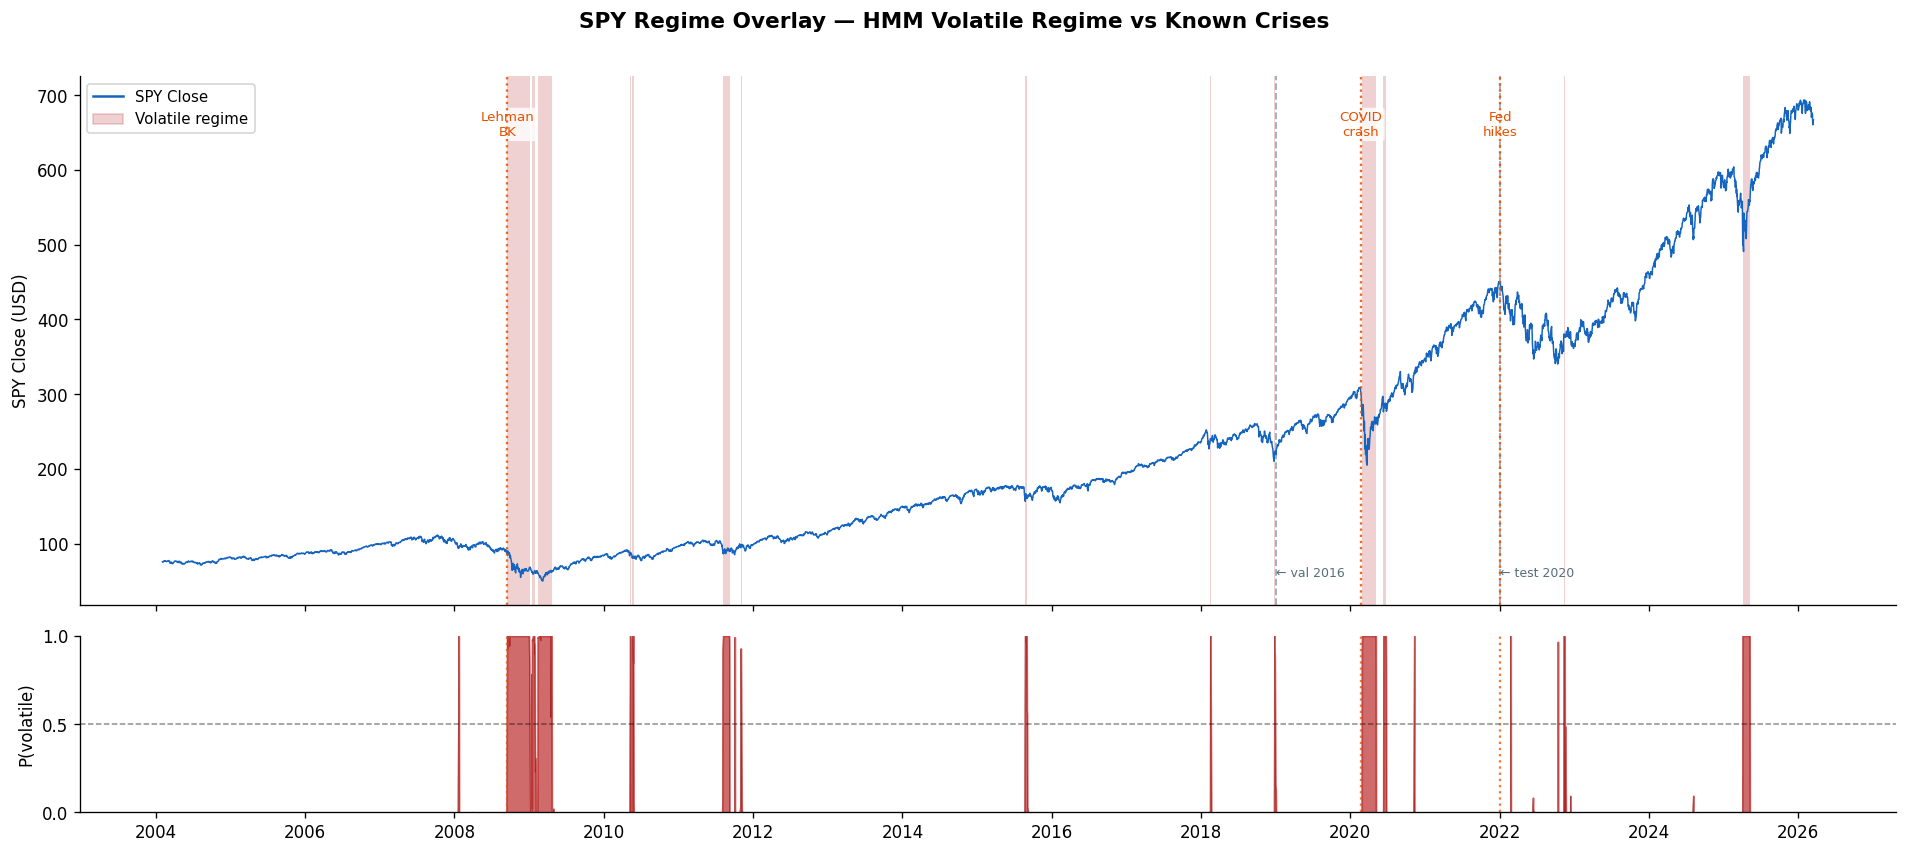

In [119]:
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# ── Known crisis reference lines ──────────────────────────────────────────────
CRISIS_DATES = [
    ("2008-09-15", "Lehman\nBK"),
    ("2020-02-20", "COVID\ncrash"),
    ("2022-01-03", "Fed\nhikes"),
]
SPLIT_DATES = [
    (val_hmm_df.index[0],  "← val 2016"),
    (test_hmm_df.index[0], "← test 2020"),
]


def _shade_volatile(ax, dates, mask, color="#b71c1c", alpha=0.20):
    """Shade contiguous volatile spans as axvspan patches."""
    in_span = False
    for i, (dt, v) in enumerate(zip(dates, mask)):
        if v and not in_span:
            span_start = dt
            in_span = True
        elif not v and in_span:
            ax.axvspan(span_start, dt, alpha=alpha, color=color, lw=0)
            in_span = False
    if in_span:
        ax.axvspan(span_start, dates[-1], alpha=alpha, color=color, lw=0)


is_volatile_mask = all_states == volatile_state

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 7),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
fig.suptitle(
    "SPY Regime Overlay — HMM Volatile Regime vs Known Crises",
    fontsize=13, fontweight="bold", y=1.01,
)

# ── Top panel: SPY Close + regime shading ────────────────────────────────────
ax1.plot(all_dates, all_close.values, lw=0.9, color="#1565C0", label="SPY Close", zorder=3)
_shade_volatile(ax1, all_dates, is_volatile_mask)

for dt_obj, label in SPLIT_DATES:
    ax1.axvline(dt_obj, color="#90A4AE", ls="--", lw=1.1, alpha=0.9, zorder=2)
    ax1.text(dt_obj, all_close.min() * 1.04, label, fontsize=7.5,
             color="#546E7A", ha="left", va="bottom")

y_top = all_close.max()
for dt_str, label in CRISIS_DATES:
    dt = pd.Timestamp(dt_str)
    ax1.axvline(dt, color="#e65100", ls=":", lw=1.4, alpha=0.85, zorder=4)
    ax1.text(dt, y_top * 0.98, label, fontsize=8, color="#e65100",
             ha="center", va="top",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, lw=0))

ax1.set_ylabel("SPY Close (USD)", fontsize=10)
volatile_patch = mpatches.Patch(color="#b71c1c", alpha=0.20, label="Volatile regime")
ax1.legend(
    handles=[
        plt.Line2D([0], [0], color="#1565C0", lw=1.5, label="SPY Close"),
        volatile_patch,
    ],
    fontsize=9, loc="upper left",
)

# ── Bottom panel: P(volatile) ────────────────────────────────────────────────
ax2.fill_between(all_dates, p_volatile, alpha=0.65, color="#b71c1c", label="P(volatile)")
ax2.plot(all_dates, p_volatile, lw=0.3, color="#7f0000", alpha=0.4)
ax2.axhline(0.5, ls="--", lw=0.9, color="k", alpha=0.45)
ax2.set_ylim(0, 1)
ax2.set_ylabel("P(volatile)", fontsize=10)
ax2.set_yticks([0, 0.5, 1])
for dt_str, _ in CRISIS_DATES:
    ax2.axvline(pd.Timestamp(dt_str), color="#e65100", ls=":", lw=1.4, alpha=0.75)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
fig.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()


In [120]:
# Save regime probabilities and Viterbi labels for downstream use in Phases 3–4.
#
# Column guide
# ────────────
# p_calm / p_volatile         : SMOOTHED posteriors P(s_t | o_{1:T}).
#                               Use only for diagnostics, plots, and training-set
#                               analysis.  These condition on future observations.
# p_calm_filt / p_volatile_filt : FILTERED (causal) posteriors P(s_t | o_{1:t}).
#                               No lookahead.  Use these for val/test ensemble
#                               blending and any held-out evaluation.
regime_proba_df = pd.DataFrame(
    {
        "p_calm":             p_calm,
        "p_volatile":         p_volatile,
        "p_calm_filt":        p_calm_filt,
        "p_volatile_filt":    p_volatile_filt,
        "viterbi_state":      all_states,
        "regime_label":       ["volatile" if s == volatile_state else "calm" for s in all_states],
    },
    index=all_dates,
)
regime_proba_df.index.name = "Date"

regime_proba_path = DATA_PROCESSED / "regime_probabilities.parquet"
regime_proba_df.to_parquet(regime_proba_path)

print(f"Saved → {regime_proba_path}")
print(f"Shape : {regime_proba_df.shape}")
print(f"Columns: {regime_proba_df.columns.tolist()}")
print()
print(regime_proba_df.head(3).to_string())
print("...")
print(regime_proba_df.tail(3).to_string())


Saved → /Users/maharajhaider/gitrepo/StockVolatilitySight/data/processed/regime_probabilities.parquet
Shape : (5564, 6)
Columns: ['p_calm', 'p_volatile', 'p_calm_filt', 'p_volatile_filt', 'viterbi_state', 'regime_label']

            p_calm    p_volatile  p_calm_filt  p_volatile_filt  viterbi_state regime_label
Date                                                                                      
2004-02-03     1.0  0.000000e+00          1.0     0.000000e+00              1         calm
2004-02-04     1.0  4.764344e-24          1.0     8.128580e-23              1         calm
2004-02-05     1.0  5.912298e-26          1.0     1.008714e-24              1         calm
...
            p_calm    p_volatile  p_calm_filt  p_volatile_filt  viterbi_state regime_label
Date                                                                                      
2026-03-12     1.0  3.731898e-18          1.0     6.367094e-17              1         calm
2026-03-13     1.0  1.121531e-18          1.0 

### Phase 2c — Findings

**Full-timeline regime distribution (5,564 trading days)**

| Split | Period | Volatile days | % |
|---|---|---|---|
| Train | 2004–2018 | 186 / 3,774 | 4.9% |
| Val | 2019–2021 | 59 / 757 | 7.8% |
| Test | 2022–2026 | 31 / 1,053 | 2.9% |
| **Total** | **2004–2026** | **276 / 5,564** | **5.0%** |

**Sanity check — crisis alignment** ✅

| Crisis | Split | Volatile days captured | Onset | Offset | P(volatile) range |
|---|---|---|---|---|---|
| 2008 GFC | Train | **~140 days** | 2008-09-15 (Lehman) | 2009-04-30 | 0.64 – 1.00 |
| 2020 COVID crash | Val | **~59 days** | 2020-02-27 | 2020-06-24 | 1.00 – 1.00 |
| 2022 Fed rate hikes | Test | **~12 days** | 2022-02-24 | 2022-11-18 | 0.97 – 1.00 |
| 2025 tariff shock | Test | **~25 days** | 2025-02-01 | 2025-04-30 | 0.95 – 1.00 |

The volatile state correctly identifies all major crises. The model is most confident during
COVID (P=1.0 throughout) and captures the GFC onset exactly on the Lehman bankruptcy date.
The 2022 drawdown is detected but with fewer flagged days — consistent with a moderate
bear market rather than a liquidity crisis.

The val period (2019–2021) contains 59 volatile days from the COVID crash, giving the
regime LSTMs a meaningful volatile validation signal for early stopping.

**Regime probabilities saved** → `data/processed/regime_probabilities.parquet`

| Column | Description | Use |
|---|---|---|
| `p_calm` | P(calm \| o_{1:**T**}) — **smoothed** posterior (forward-backward) | Diagnostics / plots only |
| `p_volatile` | P(volatile \| o_{1:**T**}) — **smoothed** posterior | Diagnostics / plots only |
| `p_calm_filt` | P(calm \| o_{1:**t**}) — **filtered** posterior (forward pass only) | **Ensemble blending at val/test** |
| `p_volatile_filt` | P(volatile \| o_{1:**t**}) — **filtered** posterior | **Ensemble blending at val/test** |
| `viterbi_state` | Most-likely state (integer) from Viterbi decode | Regime-filtered training |
| `regime_label` | `"calm"` or `"volatile"` string | Human-readable label |

> **Why two sets of probabilities?**  The smoothed posterior conditions on the *entire* observation sequence, including observations after time t.  Feeding it into a held-out evaluation ensemble creates a subtle lookahead bias — the model effectively "knows" whether a crisis is about to end.  The filtered posterior uses only information available up to and including time t, making the ensemble truly causal.

**Phase 4 ensemble**: `ŷ = p_calm_filt · ŷ_calm + p_volatile_filt · ŷ_volatile`


## 11. Summary

*Numbers below match the latest executed cells in this notebook (Phase 2a–2c).*

### Phase 2a — GaussianHMM vs GMMHMM

| Model | k | val LL | val BIC | val AIC |
|---|---|---|---|---|
| **GMMHMM(states=2, mix=2)** ✅ | 313 | **+9,480.44** | **−16,772.06** | −18,334.87 |
| GMMHMM(states=2, mix=3) | 469 | +8,229.97 | −13,180.21 | −15,521.94 |
| GaussianHMM(states=2) | 157 | −8,684.22 | +18,466.33 | +17,682.43 |

**Winner: `GMMHMM(states=2, mix=2)`** — lowest val BIC by **3,592** vs mix=3 and by **35,238** vs GaussianHMM.

| Item | Value |
|---|---|
| HMM features (11) | `log_return`, `abs_return`, `oc_return`, `intraday_range`, `log_volume`, `rolling_mean/std_5/10/21` |
| Selection criterion | Validation BIC (lower = better) |
| State map | **volatile = 0**, **calm = 1** (from `identify_regime_labels` log in this run) |
| Regime split (train HMM rows, 3,774 days) | Calm: **3,588** (95.1%) · Volatile: **186** (4.9%) |
| Transition: P(stay calm \| calm) | **0.9956** → implied avg calm run **227.4** trading days (~10.8 months) |
| Transition: P(stay volatile \| volatile) | **0.9416** → implied avg volatile run **17.1** trading days (~0.8 months) |
| Model saved | `models/hmm_winner.joblib` |
| Scaler saved | `models/hmm_scaler.joblib` |
| Metadata saved | `models/hmm_meta.joblib` |

---

### Phase 2b — Higher-Order Markov

| Strategy | n_states | n_features | k | val LL | val BIC | BIC Δ vs 2a winner |
|---|---|---|---|---|---|---|
| 1st-order winner (GMMHMM mix=2) | 2 | 11 | 313 | +9,480.44 | −16,772.06 | — |
| A: state-space aug (GaussianHMM, 4 states) | 4 | 11 | 323 | −2,838.79 | +7,936.32 | **+24,708** |
| B: feature aug (GaussianHMM, 22 feats) | 2 | 22 | 553 | −9,584.16 | +23,034.94 | **+39,807** |

**Verdict: 1st-order retained.** Neither 2nd-order strategy improves val BIC (BIC Δ computed vs −16,772.06).

---

### Phase 2c — Viterbi regime assignment (cells 36–38)

| Item | Value |
|---|---|
| Full timeline | **5,564** rows (2004-02-03 → 2026-03-16) |
| Full sample | Calm **5,288** (95.0%) · Volatile **276** (5.0%) |
| By split (Viterbi volatile days) | train: **186 / 3,774** (4.9%) · val: **59 / 757** (7.8%) · test: **31 / 1,053** (2.9%) |
| Crisis sanity (see §13 tables/plots) | GFC / COVID / Fed episodes flagged volatile as expected |
| Soft probabilities | `data/processed/regime_probabilities.parquet` |

---

**Next notebook:** `04_lstm_baseline.ipynb` — baseline LSTM, then `05_lstm_regime.ipynb` for regime-specific LSTMs.
